In [3]:
%matplotlib inline

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import sys
import pyreadstat
import scipy.stats as st

In [5]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## Phase 3 — Exploratory Data Analysis (EDA)

In this phase we will check if the merged Amsterdam–London dataset is analytically sound and suitable for discrete choice modelling. The objective is to idenitify distributional patterns, compare mode shares across the two cities, and test whether observed differences are statistically meaningful rather than descriptive noise.

The EDA is executed in the following sequence: 
1. Data integrity checks.
2. Univariate profiling.
3. City-level mode comparisons.
4. Categorical association tests.
5. Continuous-variable group tests with assumptions.
  
The goal is to ensure that inputs for our model in Phase 4 are statistically defensible and transparently documented.

### 3.1 Build Joint Analysis Dataset (Amsterdam + London)

The first step constructs one tidy analysis dataset where each row is one commuting trip and each column is a harmonized variable. This enables direct city comparisons under identical variable definitions and avoids downstream inconsistencies in statistical testing.

The code below standardizes column names where needed, aligns data types, and creates a dataset with a city indicator. We will keep only the variables required for the EDA and the upcoming MNL estimation.

In [6]:
amst_data = pd.read_csv(r"C:\Users\vladimir.koev\OneDrive - Трансметрикс АД\SoftUni\Data Science\Final Exam\data\processed\amst_processed.csv")

In [7]:
amst_data.columns

Index(['new_id', 'person_id', 'trip_id', 'new_trip_id', 'home_municipality',
       'origin_municipality', 'dest_municipality', 'origin_postcode',
       'dest_postcode', 'amsterdam_neighborhood', 'trip_purpose',
       'mode_detailed', 'mode_class', 'mode_role', 'n_legs', 'month',
       'weekday', 'is_holiday', 'departure_hour', 'departure_minute',
       'travel_time_min', 'distance_hm', 'age', 'gender', 'income_decile',
       'has_driving_license', 'n_cars_household', 'weight_trip',
       'weight_person', 'distance_km', 'n_transfers', 'has_transfer',
       'is_peak', 'chosen_mode', 'city', 'age_band', 'income_quintile'],
      dtype='object')

In [8]:
lnd_data = pd.read_csv(r"C:\Users\vladimir.koev\OneDrive - Трансметрикс АД\SoftUni\Data Science\Final Exam\data\processed\lnd_processed.csv")

In [9]:
lnd_data.columns

Index(['person_id', 'trip_id', 'trip_purpose', 'mode_detailed',
       'travel_time_min', 'distance_km', 'departure_hour', 'weekday',
       'is_holiday', 'age_band', 'gender', 'income_quintile',
       'has_driving_license', 'n_cars_household', 'weight_trip',
       'weight_person', 'city', 'is_peak', 'chosen_mode', 'n_transfers',
       'has_transfer', 'n_legs'],
      dtype='object')

In [10]:
# Keep common columns only (defensive alignment)
shared_columns = [
    "person_id", "trip_id", "trip_purpose", "mode_detailed",
    "travel_time_min", "distance_km", "departure_hour",
    "n_legs", "n_transfers","has_transfer","weekday", "is_holiday",
    "age_band", "gender", "income_quintile", "has_driving_license",
    "n_cars_household", "weight_trip", "weight_person", "city",
    "is_peak", "chosen_mode"
]

In [11]:
# Keep only needed columns for both datasets
amst_data = amst_data[[c for c in shared_columns if c in amst_data.columns]].copy()
lnd_data = lnd_data[[c for c in shared_columns if c in lnd_data.columns]].copy()

combined_data = pd.concat([amst_data, lnd_data], ignore_index = True) #Union both datasets

In [12]:
# Basic harmonization
combined_data["chosen_mode"] = combined_data.chosen_mode.astype("category")
combined_data["city"] = combined_data.city.astype("category")

In [13]:
combined_data.city.value_counts() #Londons dataset is much bigger than Amsterdams dataset

city
London       3315
Amsterdam     681
Name: count, dtype: int64

### 3.2 Data integrity checks

In this step we will verify data quality and structural integrity. This includes duplicate checks, missingness, invalid ranges, and category support by city. These checks protect against silent data issues that can bias statistical tests and model coefficients.

The goal is to do quick diagnostics and validation, not exhaustive auditing.

In [14]:
# Duplicate rows check
combined_data.duplicated(subset=["city", "trip_id"]).sum()

np.int64(0)

In [15]:
#Missing values
combined_data.isna().sum()

person_id              0
trip_id                0
trip_purpose           0
mode_detailed          0
travel_time_min        0
distance_km            0
departure_hour         0
n_legs                 0
n_transfers            0
has_transfer           0
weekday                0
is_holiday             0
age_band               0
gender                 0
income_quintile        0
has_driving_license    0
n_cars_household       0
weight_trip            0
weight_person          0
city                   0
is_peak                0
chosen_mode            0
dtype: int64

In [16]:
# Check Invalid 
invalid_ranges = {
    "negative_time": (combined_data.travel_time_min <= 0).sum(),
    "negative_dist": (combined_data.distance_km <= 0).sum(),
    "invalid_hour": (~combined_data.departure_hour.between(0, 23)).sum(),
}

In [17]:
invalid_ranges #29 records in London sets which we flagged during the dataload (-1 hour) 

{'negative_time': np.int64(0),
 'negative_dist': np.int64(0),
 'invalid_hour': np.int64(29)}

In [18]:
# Relationship/Logic checks
logic_errors = {
    "underage_commuters": (combined_data.age_band <= 3).sum(),  #Underage commuters are people in age band 1,2 and 3 (0-16 years old) 
    "transfer_mismatch": (combined_data.n_transfers != (combined_data.n_legs - 1)).sum(), # Transfer logic: n_transfers should usually be n_legs - 1
    "underage_driver": ((combined_data.age_band <= 3) & (combined_data.has_driving_license == True)).sum() # License check: if < 16-18 (depending on city), has_driving_license should be False
}

In [19]:
logic_errors #we see that we have 35 trips which have more than 1 legs but no transfers

{'underage_commuters': np.int64(0),
 'transfer_mismatch': np.int64(35),
 'underage_driver': np.int64(0)}

In [20]:
combined_data[combined_data.n_transfers != (combined_data.n_legs - 1)][["chosen_mode","city"]].value_counts().sort_index()

chosen_mode  city     
bike         Amsterdam    22
             London        2
car          Amsterdam     5
             London        6
Name: count, dtype: int64

In [21]:
combined_data[combined_data.n_transfers != (combined_data.n_legs - 1)]

,person_id,trip_id,trip_purpose,mode_detailed,travel_time_min,distance_km,departure_hour,n_legs,n_transfers,has_transfer,...,age_band,gender,income_quintile,has_driving_license,n_cars_household,weight_trip,weight_person,city,is_peak,chosen_mode
49,2.708820e+11,2.708820e+13,1.0,8.0,30.0,2.500000,22.0,2.0,0,0,...,6,2.0,5,0.0,0.0,166071.066206,454.989222,Amsterdam,0,bike
74,2.713987e+11,2.713987e+13,1.0,8.0,45.0,12.000000,8.0,3.0,0,0,...,7,1.0,5,1.0,1.0,64594.869619,176.972246,Amsterdam,1,bike
75,2.713987e+11,2.713987e+13,1.0,8.0,45.0,11.000000,16.0,3.0,0,0,...,7,1.0,5,1.0,1.0,64594.869619,176.972246,Amsterdam,0,bike
129,2.720820e+11,2.720820e+13,1.0,1.0,80.0,25.200000,6.0,3.0,0,0,...,7,2.0,2,1.0,1.0,175943.997410,482.038349,Amsterdam,0,car
130,2.720820e+11,2.720820e+13,1.0,1.0,73.0,24.700000,21.0,3.0,0,0,...,7,2.0,2,1.0,1.0,175943.997410,482.038349,Amsterdam,0,car
154,2.724720e+11,2.724720e+13,1.0,1.0,30.0,7.400000,8.0,2.0,0,0,...,6,1.0,5,1.0,1.0,56311.672961,154.278556,Amsterdam,1,car
155,2.724720e+11,2.724720e+13,1.0,1.0,30.0,7.400000,17.0,2.0,0,0,...,6,1.0,5,1.0,1.0,56311.672961,154.278556,Amsterdam,1,car
158,2.725720e+11,2.725720e+13,1.0,8.0,25.0,4.000000,8.0,3.0,0,0,...,9,1.0,3,1.0,1.0,38794.474756,106.286232,Amsterdam,1,bike
159,2.725720e+11,2.725720e+13,1.0,8.0,30.0,3.500000,13.0,3.0,0,0,...,9,1.0,3,1.0,1.0,38794.474756,106.286232,Amsterdam,0,bike
166,2.726030e+11,2.726030e+13,1.0,8.0,23.0,1.700000,7.0,3.0,0,0,...,9,2.0,3,1.0,0.0,83413.060883,228.528934,Amsterdam,1,bike


### 3.3 Descriptive Univariate EDA

In this step we are going to check the distributions of key behavioural and socioeconomic variables. This will set the baseline context and helps detect asymmetry, concentration, or sparse categories that may affect test validity and model stability.

We inspect central tendency and spread for continuous variables, and frequency distributions for categorical variables.

In [22]:
combined_data.groupby("city").travel_time_min.describe().T.round(2)

C:\Users\vladimir.koev\AppData\Local\Temp\ipykernel_11432\1462392510.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combined_data.groupby("city").travel_time_min.describe().T.round(2)


city,Amsterdam,London
count,681.00,3315.00
mean,27.89,36.72
std,15.88,18.65
min,2.00,5.00
25%,15.00,25.00
50%,25.00,30.00
75%,35.00,45.00
max,120.00,120.00


Firstly, we need to mention that the Londons' sample is much bigger than the Amsterdam data. Apart from that we see very interesting and distinct differences between both city commuters. 

Londoners travel longer: The mean travel time in London (36.72 min) which is more with 8 mins (nearly 30%) longer than in Amsterdam. 25% of Amsterdam commuters reach their destination in just 15 mins while in London even the "quick" commuters spend 25mins. We can say that there is actually no "quick" commuters in London as the 50% quartile is just 5mins longer than the 25% compared to Amsterdam where the difference is 10 mins (+50% longer trip). However, the "typical" journey for both cities is about 30 mins      

London has a higher standard deviation (18.65), suggesting more unpredictable traffic or wider geographical dispersion compared to Amsterdam.  


In [23]:
combined_data.groupby("city").distance_km.describe().T.round(2)

C:\Users\vladimir.koev\AppData\Local\Temp\ipykernel_11432\3938683810.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combined_data.groupby("city").distance_km.describe().T.round(2)


city,Amsterdam,London
count,681.00,3315.00
mean,9.83,11.24
std,10.30,7.83
min,0.20,0.32
25%,3.00,4.83
50%,6.00,9.66
75%,12.00,16.09
max,50.00,48.28


In line with our comment that London commuters do not have 'short trips' in terms of travel time, we see that they cover much longer distances compared to Amsterdam commuters. In London the bottom 25% distnaces extends to nearly 5 km compared to 3km in Amsterdam.This is a significant jump; 5 km is on the edge of what many people consider a "short" or walkable trip, forcing a higher reliance on motorized transport early on.

While  Amsterdam has a "short-trip" profile where 50% of the commuting trips are 6 km or less (very bike-friendly distances), the "typical" trip in London is over 60% longer being almost 10kms. Generally, in London, more than 50% of trips are longer than 9.66 km, moving the typical trip into the territory where cars or public transit become much more attractive than active travel.   

Lastly, to mention that Amsterdam’s trip distance has a standard deviation (10.30) higher than its mean (9.83) indicatating a high right-skewness of the data. Most people are making very short trips (under 6 km), but a few people traveling 50 km are inflating the "average.In London, the Mean (11.24) and Median (9.66) are much closer. This suggests London trip distances are more "normally distributed" or evenly spread across the population.

In [24]:
# Categorical frequency snapshots
for variable in ["chosen_mode", "age_band", "income_quintile", "gender", "has_driving_license"]:
    freq_table = (combined_data[variable].value_counts(dropna = False).sort_index().to_frame("count") .assign(pct = lambda x: (x["count"] / x["count"].sum() * 100).round(1))
    )
    print(f"\nFrequency — {variable}")
    print(freq_table.head(10))


Frequency — chosen_mode
             count   pct
chosen_mode             
bike           690  17.3
car           1431  35.8
pt            1875  46.9

Frequency — age_band
          count   pct
age_band             
4            72   1.8
5           857  21.4
6          1044  26.1
7           801  20.0
8           806  20.2
9           416  10.4

Frequency — income_quintile
                 count   pct
income_quintile             
1                  601  15.0
2                  582  14.6
3                  534  13.4
4                  895  22.4
5                 1384  34.6

Frequency — gender
        count   pct
gender             
1.0      2036  51.0
2.0      1960  49.0

Frequency — has_driving_license
                     count   pct
has_driving_license             
0.0                   1038  26.0
1.0                   2958  74.0


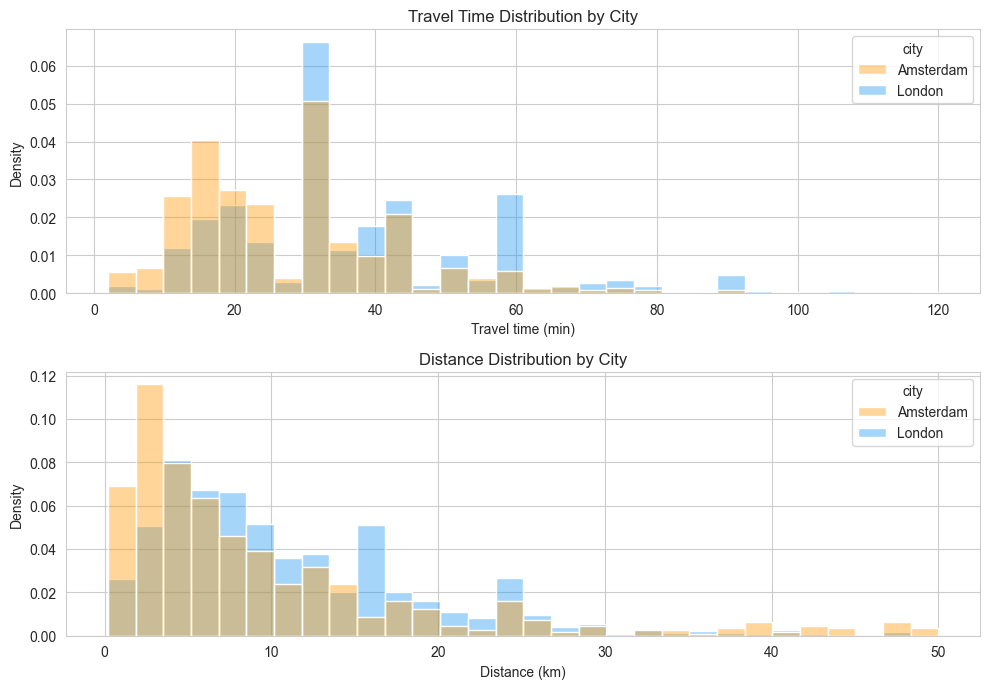

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))

city_colors = {"Amsterdam": "#FF9800", "London": "#2196F3"}

# Plot 1: Travel Time
sns.histplot(
    data = combined_data, x = "travel_time_min", hue = "city",
    bins = 30, stat = "density", common_norm = False, 
    palette = city_colors,
    alpha = 0.4, # Transparency (0 is clear, 1 is solid),
    # fill = True,
    ax = axes[0]
)
axes[0].set_title("Travel Time Distribution by City")
axes[0].set_xlabel("Travel time (min)")
axes[0].set_ylabel("Density")

# Plot 2: Distance
sns.histplot(
    data = combined_data, x = "distance_km", hue = "city",
    bins = 30, stat = "density", common_norm=False,
    palette = city_colors,
    alpha=0.4,
    # fill=True,
    ax=axes[1]
)
axes[1].set_title("Distance Distribution by City")
axes[1].set_xlabel("Distance (km)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

### 3.4 Mode-Share Baseline: Amsterdam vs London

Mode share is the core descriptive result for this project. We compute both unweighted and survey-weighted city-level shares to separate sample composition effects from population-representative patterns.

This comparison provides the empirical baseline that motivates the city-specific MNL models in Phase 4.

In [26]:
# Unweighted mode share
mode_share_unweighted = (
    pd.crosstab(combined_data.city, combined_data.chosen_mode, normalize="index").mul(100).round(1))

In [27]:
mode_share_unweighted

chosen_mode,bike,car,pt
city,,,
Amsterdam,59.8,26.4,13.8
London,8.5,37.7,53.7


In [28]:
# Weighted mode share using trip weights
weighted_counts = (
    combined_data.groupby(["city", "chosen_mode"], observed=False).weight_trip.sum().rename("weighted_sum").reset_index().round(0)
)

In [29]:
weighted_totals = weighted_counts.groupby("city").weighted_sum.transform("sum")
weighted_counts["weighted_pct"] = (weighted_counts.weighted_sum / weighted_totals * 100).round(1)

mode_share_weighted = weighted_counts.pivot(index="city", columns="chosen_mode", values="weighted_pct").fillna(0)

C:\Users\vladimir.koev\AppData\Local\Temp\ipykernel_11432\2261340848.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weighted_totals = weighted_counts.groupby("city").weighted_sum.transform("sum")


In [30]:
weighted_counts

,city,chosen_mode,weighted_sum,weighted_pct
0,Amsterdam,bike,48648265.0,60.1
1,Amsterdam,car,19790012.0,24.4
2,Amsterdam,pt,12511701.0,15.5
3,London,bike,353.0,9.4
4,London,car,1270.0,33.7
5,London,pt,2151.0,57.0


In [31]:
mode_share_weighted

chosen_mode,bike,car,pt
city,,,
Amsterdam,60.1,24.4,15.5
London,9.4,33.7,57.0


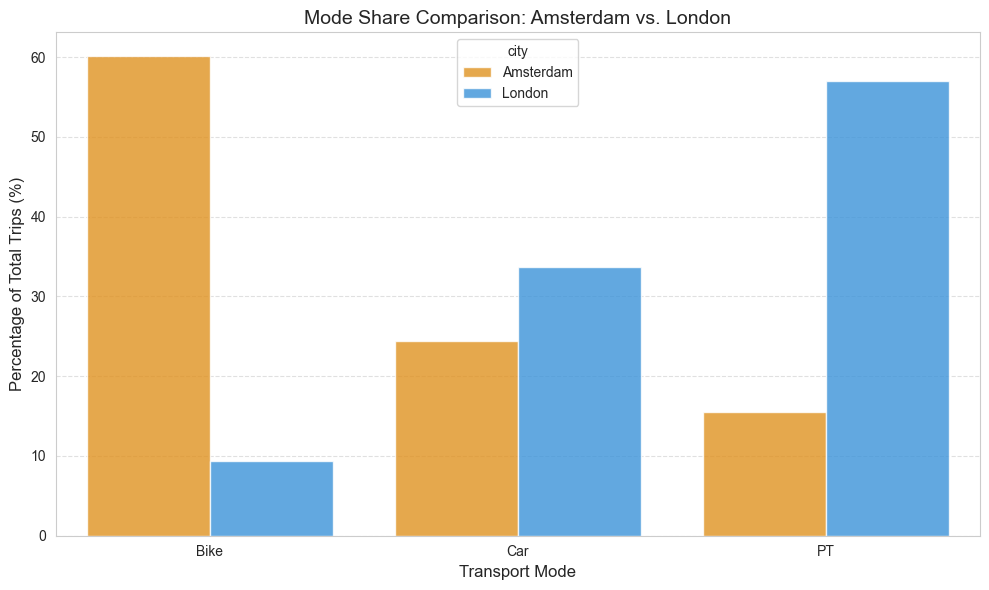

In [36]:
city_colors = {"Amsterdam": "#FF9800", "London": "#2196F3"}
chosen_modes = weighted_counts.chosen_mode.unique()


plt.figure(figsize=(10, 6))
sns.barplot(
    data = weighted_counts, 
    x = "chosen_mode", 
    y = "weighted_pct", 
    hue="city",
    palette = city_colors, # Using your city colors
    alpha=0.8
)

plt.title("Mode Share Comparison: Amsterdam vs. London", fontsize=14)
plt.xlabel("Transport Mode", fontsize=12)
plt.ylabel("Percentage of Total Trips (%)", fontsize=12)

plt.xticks(
    ticks = range(len(chosen_modes)), 
    labels = [str(m).upper() if m == 'pt' else str(m).title() for m in chosen_modes]
)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### 3.5 Cross-tabs and Chi-Squared Tests (Categorical Association)

We now are going to test if mode choice is statistically associated with city and the socioeconomic factors in our dataset. For each test, we assume a null hypothesis where variables are independent and commuting mode choice is completely random. The alternative hyphotesis is association between the variables for mode choice.

For all tests we use significance level ($\alpha = 0.05$). We report ($\chi^2$), degrees of freedom, p-value, and check expected cell counts to validate test assumptions.

In [ ]:
alpha = 0.05

In [39]:
def run_chi2_test(data, var_a, var_b, alpha = 0.05):
    contingency = pd.crosstab(data[var_a], data[var_b])
    chi2_stat, p_value, dof, expected = st.chi2_contingency(contingency)
    expected_lt5 = (expected < 5).sum()
    total_cells = expected.size
    
    result = {
        "test": f"{var_a} vs {var_b}",
        "chi2": round(chi2_stat, 3),
        "dof": int(dof),
        "p_value": round(p_value, 6),
        "reject_h0": p_value < alpha,
        "expected_cells_lt5": int(expected_lt5),
        "total_cells": int(total_cells),
    }
    return contingency, result

chi2_pairs = [
    ("chosen_mode", "city"),
    ("chosen_mode", "income_quintile"),
    ("chosen_mode", "has_driving_license"),
    ("chosen_mode", "age_band"),
    ("chosen_mode", "is_peak")
]

chi2_results = []
for var_a, var_b in chi2_pairs:
    ctab, res = run_chi2_test(combined_data, var_a, var_b, alpha = alpha)
    chi2_results.append(res)
    print(f"\nContingency table: {var_a} x {var_b}")
    print(ctab)

chi2_results_table = pd.DataFrame(chi2_results)
print("\nChi-squared test summary")
print(chi2_results_table)


Contingency table: chosen_mode x city
city         Amsterdam  London
chosen_mode                   
bike               407     283
car                180    1251
pt                  94    1781

Contingency table: chosen_mode x income_quintile
income_quintile    1    2    3    4    5
chosen_mode                             
bike              75   73   88  187  267
car              207  228  227  391  378
pt               319  281  219  317  739

Contingency table: chosen_mode x has_driving_license
has_driving_license  0.0   1.0
chosen_mode                   
bike                 153   537
car                    5  1426
pt                   880   995

Contingency table: chosen_mode x age_band
age_band      4    5    6    7    8    9
chosen_mode                             
bike          9  141  195  167  104   74
car          22  125  294  329  439  222
pt           41  591  555  305  263  120

Contingency table: chosen_mode x is_peak
is_peak        0     1
chosen_mode           
bike  

From our results above we can say that there is a significant relationship across every single pair of variables we tested. Our p-values are all essentially zero ($P \leq 0$ ) for all cases, we reject the Null Hypothesis. We can assume that the commuters mode choices are not random. Commuters are heavily influenced by the city they live in, their income, age, license status, and whether they are traveling during peak hours.

The city variable shows the strongest results among all variables. Amsterdam shows a clear preference for cycling, while London’s modal share is heavily dominated by Public Transport (PT) and cars.  

The results for commuters with a driving license is very interesting. Our data shows a shows a significant split in mode choice. Commuters without a driving license rely heavily on PT (880) while those with a license split between cars and PT, but their car usage jumps significantly.

Regarding the income it is important to notice that as income of commuters increases (from 1 to 5), the total number of trips increases as well. Interestingly, PT and bike usage spikes in the highest income quintile (739 and 267 respectively), suggesting that in Amsterdam and London, PT and bikes are a preferred or necessary choice even for the high earners.

Younger groups (bands 4-5) show a very high reliance on PT. As the age bands increase (7-8), car usage grows significantly and eventually becomes the dominant mode.

### 3.6 Continuous-Variable Group Tests (ANOVA)

In this part we are going to test if average travel time and distance differ across chosen modes. We assume a null hypothesis where the averages of each group are equal (ANOVA), while the alternative hypothesis is that at least one mode average differs.

We are going to assume that if normality and variance are reasonably satisfied, use one-way ANOVA. We report test statistic, p-value, and degrees of freedom where applicable, with \(\alpha = 0.05\).

To determine if transport modes (Car, PT, Bike) differ significantly in terms of trip duration and distance, we are going to utilize a combination of Parametric and Non-Parametric tests. Before comparing means with the standard Anova test, we must check if our data actually meets the assumtion for homogeneity of variance  (Levene, 1960). Levene’s test is used for this purpose to assess if the "spread" or variance of our data is equal across all groups (Car, PT, and Bike). We need to apply the test because the standard One-way ANOVA is sensitive to unequal variances. If one group (e.g., Car) has a much wider range of travel times than another (e.g., Bike), the ANOVA result becomes unreliable, increasing the risk of a Type I error (false positive).

Our test logic is considering a Null Hypothesis that the population variances are equal. If the p-value is less than 0.05, we reject the assumption of equal variance. This indicates "Heteroscedasticity," making standard ANOVA results invalid for our data.

If our data fail the Levene’s test (unequal variance) and transport data is non-normally distributed (containing many outliers and long-distance trips), we are going to rely on the Kruskal-Wallis test (Kruskal & Wallis, 1952). Kruskal-Wallis is a non-parametric alternative to One-way ANOVA. It does not assume a normal distribution or equal variances. Instead of comparing actual means, the test is going to convert all travel times and distances into ranks (1st, 2nd, 3rd, etc.). Then it will compares the mean ranks of the different transport modes to see if one group consistently ranks higher or lower than the others.
H-Statistic: Represents how much the ranks differ between groups.

In [44]:
def mode_groups(data, value_col):
    return [
        data.loc[data.chosen_mode == mode, value_col].dropna().values
        for mode in ["car", "pt", "bike"]
    ]

def run_anova_kruskal(data, value_col, alpha=0.05):
    groups = mode_groups(data, value_col)
    
    # Assumption checks
    # Levene for homogeneity
    levene_stat, levene_p = st.levene(*groups, center = "median")
    
    # ANOVA
    f_stat, f_p = st.f_oneway(*groups)
    
    # Kruskal
    h_stat, h_p = st.kruskal(*groups)
    
    # df for one-way ANOVA: k-1, N-k
    k = len(groups)
    n_total = sum(len(g) for g in groups)
    df_between = k - 1
    df_within = n_total - k
    
    result = {
        "variable": value_col,
        "levene_p": round(levene_p, 6),
        "anova_f": round(f_stat, 3),
        "anova_p": round(f_p, 6),
        "anova_df_between": df_between,
        "anova_df_within": df_within,
        "kruskal_h": round(h_stat, 3),
        "kruskal_p": round(h_p, 6),
        "anova_reject_h0": f_p < alpha,
        "kruskal_reject_h0": h_p < alpha
    }
    return result

test_vars = ["travel_time_min", "distance_km"]
continuous_test_results = pd.DataFrame([run_anova_kruskal(combined_data, v, alpha) for v in test_vars])
print(continuous_test_results)

          variable  levene_p  anova_f  anova_p  anova_df_between  \
0  travel_time_min       0.0  307.469      0.0                 2   
1      distance_km       0.0  207.157      0.0                 2   

   anova_df_within  kruskal_h  kruskal_p  anova_reject_h0  kruskal_reject_h0  
0             3993    643.564        0.0             True               True  
1             3993    459.670        0.0             True               True  


We performed a comparative analysis of Travel Time and Trip Distance across transport modes using Kruskal-Wallis H-tests since our data did not pass the Levene test. The Levene’s test for homogeneity of variance was significant ($P \leq 0.05$) for both variables, indicating unequal variances across groups.  Hence, we applied the non-parametric Kruskal-Wallis test.

The results of our test confirmed that there is a significant differences in both travel duration and trip distances between modes.
From the results we can conclude that transport mode choice of commuters in Amsterdam and London is not just a matter of preference but is strongly associated with the physical constraints of the trip (how far it is) and the temporal cost (how long it takes).

References:

[1] Levene, H. (1960). Robust tests for equality of variances. In Contributions to Probability and Statistics: Essays in Honor of Harold Hotelling.

[2] Kruskal, W. H., & Wallis, W. A. (1952). Use of ranks in one-criterion variance analysis. Journal of the American Statistical Association.